Veriler yükleniyor...
Eğitim Seti Boyutu: (56000, 24)
Test Seti Boyutu: (24000, 23)

--- Eğitim Seti Sütun Bilgileri ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi

,count,mean,std,min,25%,50%,75%,max
id,56000.0,28000.500000,16165.951874,1.0,14000.750000,28000.500000,42000.250000,56000.0
yas,56000.0,34.714446,11.052508,18.0,26.000000,33.000000,42.000000,69.0
vucut_kitle_indeksi,54248.0,26.273651,4.495138,16.0,23.175279,26.225806,29.321503,45.0
rem_yuzdesi,56000.0,20.233500,3.442993,10.0,17.951724,20.302218,22.598180,30.0
derin_uyku_yuzdesi,56000.0,20.246063,4.300421,5.0,17.337866,20.292151,23.227117,30.0
uykuya_dalma_suresi_dk,56000.0,20.107536,8.063278,1.0,14.000000,20.000000,25.000000,58.0
gecelik_uyanma_sayisi,56000.0,3.344929,2.034618,0.0,2.000000,3.000000,5.000000,8.0
uyku_oncesi_kafein_mg,54537.0,42.110952,72.154159,0.0,0.000000,3.000000,77.000000,400.0
uyku_oncesi_ekran_suresi_dk,56000.0,63.511446,44.590737,2.0,30.000000,51.000000,84.000000,180.0
gunluk_adim_sayisi,56000.0,7493.197554,3462.699361,500.0,5042.000000,7426.000000,9876.000000,20000.0


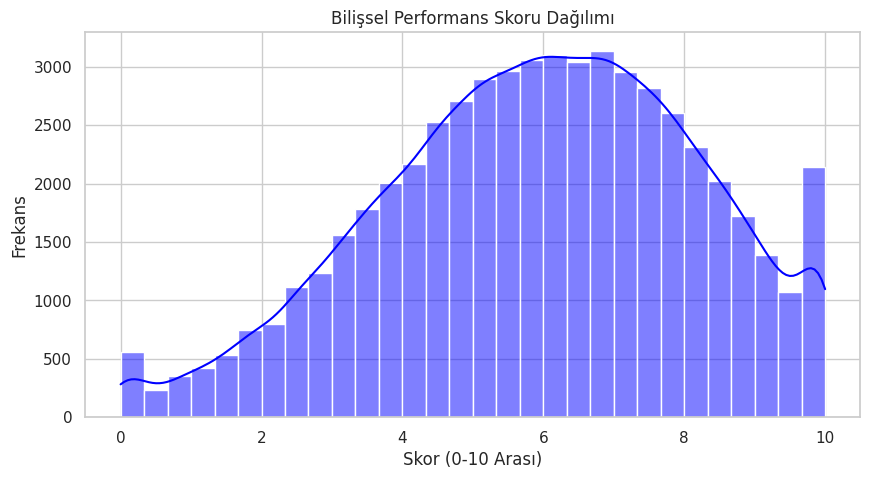


Kategorik Değişkenler: ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']
Sayısal Değişkenler: ['id', 'yas', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'bilissel_performans_skoru']


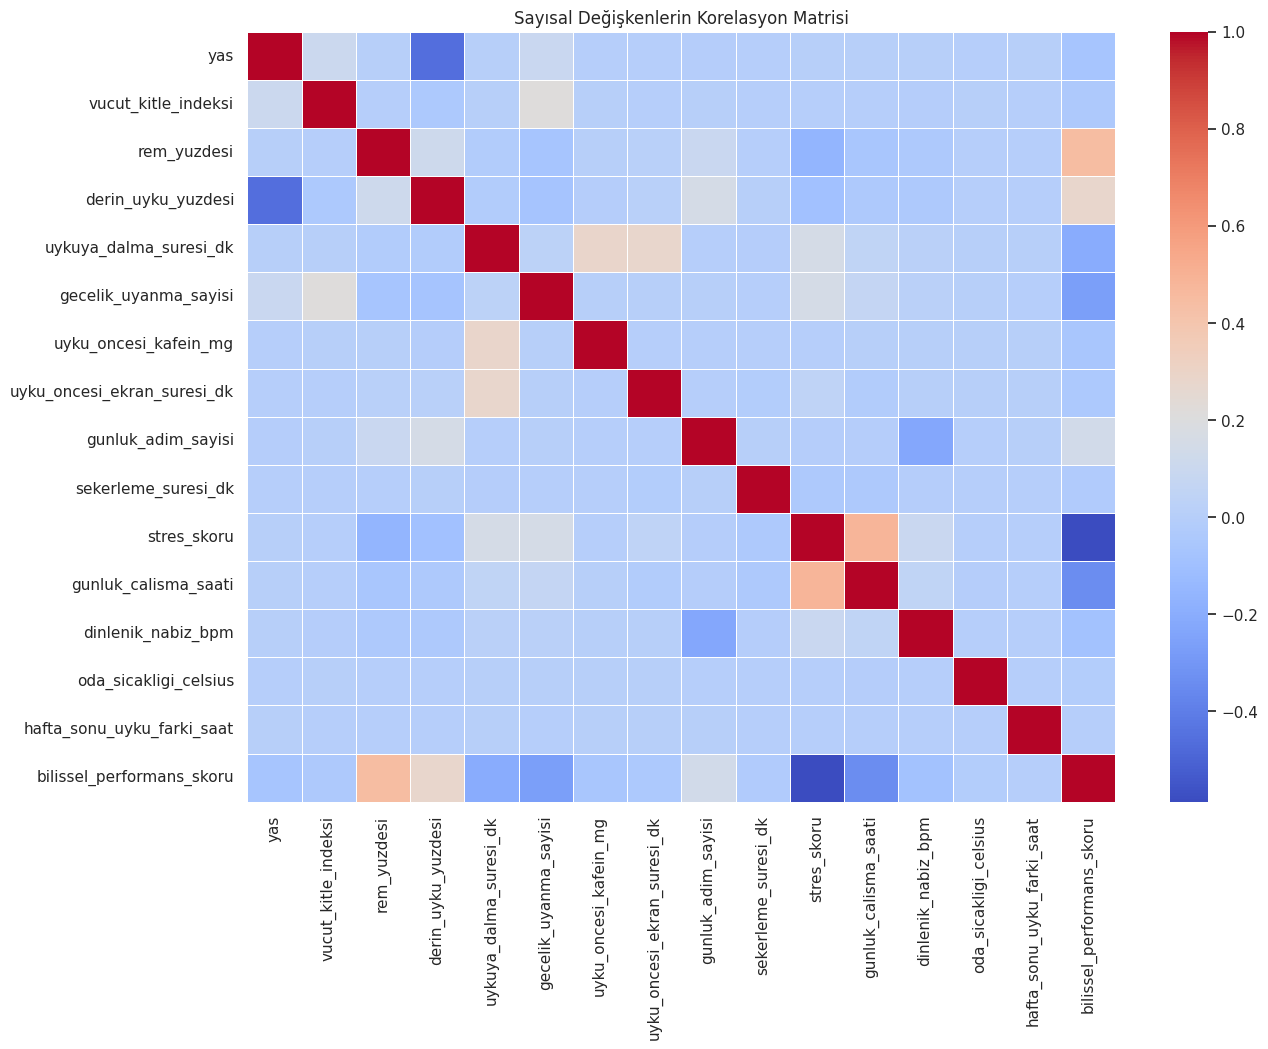


--- Bilişsel Performans Skoru ile En Yüksek Korelasyona Sahip Değişkenler ---
bilissel_performans_skoru      1.000000
rem_yuzdesi                    0.442999
derin_uyku_yuzdesi             0.280006
gunluk_adim_sayisi             0.134042
hafta_sonu_uyku_farki_saat    -0.001648
oda_sicakligi_celsius         -0.011992
sekerleme_suresi_dk           -0.023683
vucut_kitle_indeksi           -0.037990
uyku_oncesi_ekran_suresi_dk   -0.044631
uyku_oncesi_kafein_mg         -0.062387
yas                           -0.070659
dinlenik_nabiz_bpm            -0.089389
uykuya_dalma_suresi_dk        -0.207349
gecelik_uyanma_sayisi         -0.270349
gunluk_calisma_saati          -0.342112
stres_skoru                   -0.586676
Name: bilissel_performans_skoru, dtype: float64


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grafikler için genel tema ayarı
sns.set_theme(style="whitegrid")

# 1. Verileri Yükleme
print("Veriler yükleniyor...")
train = pd.read_csv('train.csv')
test = pd.read_csv('test_x.csv')
sample_sub = pd.read_csv('sample_submission.csv')

# 2. Genel Boyut ve Temel Bilgiler
print(f"Eğitim Seti Boyutu: {train.shape}")
print(f"Test Seti Boyutu: {test.shape}")
print("\n--- Eğitim Seti Sütun Bilgileri ---")
train.info()

# 3. Eksik Değer (Missing Value) Analizi
print("\n--- Eğitim Setindeki Eksik Değerler ---")
eksik_train = train.isnull().sum()
print(eksik_train[eksik_train > 0].sort_values(ascending=False))

print("\n--- Test Setindeki Eksik Değerler ---")
eksik_test = test.isnull().sum()
print(eksik_test[eksik_test > 0].sort_values(ascending=False))

# 4. İstatistiksel Özet
print("\n--- Sayısal Değişkenlerin İstatistiksel Özeti ---")
display(train.describe().T)

# 5. Hedef Değişkenin (Bilişsel Performans Skoru) Dağılımı
plt.figure(figsize=(10, 5))
sns.histplot(train['bilissel_performans_skoru'], kde=True, bins=30, color='blue')
plt.title('Bilişsel Performans Skoru Dağılımı')
plt.xlabel('Skor (0-10 Arası)')
plt.ylabel('Frekans')
plt.show()

# 6. Kategorik ve Sayısal Değişkenleri Ayırma
kategorik_sutunlar = train.select_dtypes(include=['object']).columns.tolist()
sayisal_sutunlar = train.select_dtypes(exclude=['object']).columns.tolist()

print(f"\nKategorik Değişkenler: {kategorik_sutunlar}")
print(f"Sayısal Değişkenler: {sayisal_sutunlar}")

# 7. Sayısal Değişkenlerin Hedef Değişken ile Korelasyonu
# Sadece sayısal sütunların korelasyonunu hesaplıyoruz ('id' sütununu çıkarıyoruz)
sayisal_sutunlar_id_haric = [col for col in sayisal_sutunlar if col != 'id']
korelasyon_matrisi = train[sayisal_sutunlar_id_haric].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(korelasyon_matrisi, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Sayısal Değişkenlerin Korelasyon Matrisi')
plt.show()

# Hedef değişkenle en çok korele olan özellikler
print("\n--- Bilişsel Performans Skoru ile En Yüksek Korelasyona Sahip Değişkenler ---")
hedef_korelasyon = korelasyon_matrisi['bilissel_performans_skoru'].sort_values(ascending=False)
print(hedef_korelasyon)

In [42]:
# 'cinsiyet' sütunundaki 'Erkek' değerlerini 1, 'Kadin' değerlerini 0 yapıyoruz.
train['cinsiyet'] = train['cinsiyet'].map({'Erkek': 1, 'Kadin': 0})

# İşlemin doğru yapıldığını teyit edelim:
print("--- Eğitim Seti (Train) Cinsiyet Dağılımı ---")
# Eksik veri (NaN) oluşup oluşmadığını görmek için dropna=False ekliyoruz
print(train['cinsiyet'].value_counts(dropna=False))

print("\n--- Train Seti İlk 5 Satır (Sadece Cinsiyet) ---")
print(train[['id', 'cinsiyet']].head())

# 'cinsiyet' sütunundaki 'Erkek' değerlerini 1, 'Kadin' değerlerini 0 yapıyoruz.
test['cinsiyet'] = test['cinsiyet'].map({'Erkek': 1, 'Kadin': 0})

# İşlemin doğru yapıldığını teyit edelim:
print("--- Eğitim Seti (Test) Cinsiyet Dağılımı ---")
# Eksik veri (NaN) oluşup oluşmadığını görmek için dropna=False ekliyoruz
print(test['cinsiyet'].value_counts(dropna=False))

print("\n--- Test Seti İlk 5 Satır (Sadece Cinsiyet) ---")
print(test[['id', 'cinsiyet']].head())

--- Eğitim Seti (Train) Cinsiyet Dağılımı ---
cinsiyet
0    28676
1    27324
Name: count, dtype: int64

--- Train Seti İlk 5 Satır (Sadece Cinsiyet) ---
   id  cinsiyet
0   1         1
1   2         0
2   3         1
3   4         0
4   5         0
--- Eğitim Seti (Test) Cinsiyet Dağılımı ---
cinsiyet
0    12259
1    11741
Name: count, dtype: int64

--- Test Seti İlk 5 Satır (Sadece Cinsiyet) ---
   id  cinsiyet
0   1         1
1   2         0
2   3         1
3   4         0
4   5         0


In [43]:
# 1. Ülke isimlerini standartlaştırmak için bir düzeltme sözlüğü oluşturuyoruz
ulke_duzeltmeleri = {
    'South Korea': 'Guney Kore',
    'Spain': 'Ispanya',
    'Sweden': 'Isvec',
    'Mexico': 'Meksika',
    'Netherlands': 'Hollanda'
}

# 2. replace() fonksiyonu ile hatalı/İngilizce isimleri Türkçeleriyle değiştiriyoruz
train['ulke'] = train['ulke'].replace(ulke_duzeltmeleri)

# 3. İsimlerin düzeldiğinden emin olmak için listeyi tekrar kontrol edelim
print("--- Düzeltilmiş Ülke Dağılımı ---")
print(train['ulke'].value_counts())
print(f"\nToplam Benzersiz Ülke Sayısı: {train['ulke'].nunique()}\n")

# 4. Artık tertemiz verimizle One-Hot Encoding işlemini yapabiliriz
train = pd.get_dummies(train, columns=['ulke'], dtype=int)

# 5. Sonucu ve yeni sütun isimlerini görelim
ulke_sutunlari = [col for col in train.columns if 'ulke_' in col]
print("--- Yeni Oluşan Ülke Sütunları ---")
print(ulke_sutunlari)

print("\n--- İlk 5 Satır (Sadece Ülke Sütunları) ---")
print(train[ulke_sutunlari].head())

# 1. Ülke isimlerini standartlaştırmak için bir düzeltme sözlüğü oluşturuyoruz
ulke_duzeltmeleri = {
    'South Korea': 'Guney Kore',
    'Spain': 'Ispanya',
    'Sweden': 'Isvec',
    'Mexico': 'Meksika',
    'Netherlands': 'Hollanda'
}

# 2. replace() fonksiyonu ile hatalı/İngilizce isimleri Türkçeleriyle değiştiriyoruz
test['ulke'] = test['ulke'].replace(ulke_duzeltmeleri)

# 3. İsimlerin düzeldiğinden emin olmak için listeyi tekrar kontrol edelim
print("--- Düzeltilmiş Ülke Dağılımı ---")
print(test['ulke'].value_counts())
print(f"\nToplam Benzersiz Ülke Sayısı: {test['ulke'].nunique()}\n")

# 4. Artık tertemiz verimizle One-Hot Encoding işlemini yapabiliriz
test = pd.get_dummies(test, columns=['ulke'], dtype=int)

# 5. Sonucu ve yeni sütun isimlerini görelim
ulke_sutunlari = [col for col in test.columns if 'ulke_' in col]
print("--- Yeni Oluşan Ülke Sütunları ---")
print(ulke_sutunlari)

print("\n--- İlk 5 Satır (Sadece Ülke Sütunları) ---")
print(test[ulke_sutunlari].head())

--- Düzeltilmiş Ülke Dağılımı ---
ulke
Ingiltere       11324
Cin              9989
Guney Kore       6648
Amerika          4447
Arjantin         3973
Ispanya          3962
Fransa           3440
Isvec            3364
Yeni Zelanda     2777
Portekiz         2204
Meksika          2165
Hollanda         1707
Name: count, dtype: int64

Toplam Benzersiz Ülke Sayısı: 12

--- Yeni Oluşan Ülke Sütunları ---
['ulke_Amerika', 'ulke_Arjantin', 'ulke_Cin', 'ulke_Fransa', 'ulke_Guney Kore', 'ulke_Hollanda', 'ulke_Ingiltere', 'ulke_Ispanya', 'ulke_Isvec', 'ulke_Meksika', 'ulke_Portekiz', 'ulke_Yeni Zelanda']

--- İlk 5 Satır (Sadece Ülke Sütunları) ---
   ulke_Amerika  ulke_Arjantin  ulke_Cin  ulke_Fransa  ulke_Guney Kore  \
0             0              0         1            0                0   
1             1              0         0            0                0   
2             0              0         0            0                0   
3             0              0         0            0        

In [44]:
# 1. Mevsim Sütununu Kodlama (Ilkbahar-Yaz: 1, Sonbahar-Kis: 0)
train['mevsim'] = train['mevsim'].map({'Ilkbahar-Yaz': 1, 'Sonbahar-Kis': 0})

# 2. Gün Tipi Sütununu Kodlama (Hafta sonu: 1, Hafta ici: 0)
train['gun_tipi'] = train['gun_tipi'].map({'Hafta sonu': 1, 'Hafta ici': 0})

# 3. Sonuçların Kontrolü
print("--- Mevsim Sütunu (1/0) Dağılımı ---")
print(train['mevsim'].value_counts(dropna=False))

print("\n--- Gün Tipi Sütunu (1/0) Dağılımı ---")
print(train['gun_tipi'].value_counts(dropna=False))

print("\n--- İlk 5 Satır Önizlemesi ---")
print(train[['id', 'mevsim', 'gun_tipi']].head())

# 1. Mevsim Sütununu Kodlama (Ilkbahar-Yaz: 1, Sonbahar-Kis: 0)
test['mevsim'] = test['mevsim'].map({'Ilkbahar-Yaz': 1, 'Sonbahar-Kis': 0})

# 2. Gün Tipi Sütununu Kodlama (Hafta sonu: 1, Hafta ici: 0)
test['gun_tipi'] = test['gun_tipi'].map({'Hafta sonu': 1, 'Hafta ici': 0})

# 3. Sonuçların Kontrolü
print("--- Mevsim Sütunu (1/0) Dağılımı ---")
print(test['mevsim'].value_counts(dropna=False))

print("\n--- Gün Tipi Sütunu (1/0) Dağılımı ---")
print(test['gun_tipi'].value_counts(dropna=False))

print("\n--- İlk 5 Satır Önizlemesi ---")
print(test[['id', 'mevsim', 'gun_tipi']].head())

--- Mevsim Sütunu (1/0) Dağılımı ---
mevsim
1    28143
0    27857
Name: count, dtype: int64

--- Gün Tipi Sütunu (1/0) Dağılımı ---
gun_tipi
0    40052
1    15948
Name: count, dtype: int64

--- İlk 5 Satır Önizlemesi ---
   id  mevsim  gun_tipi
0   1       0         0
1   2       0         0
2   3       1         1
3   4       0         1
4   5       0         0
--- Mevsim Sütunu (1/0) Dağılımı ---
mevsim
1    12069
0    11931
Name: count, dtype: int64

--- Gün Tipi Sütunu (1/0) Dağılımı ---
gun_tipi
0    17112
1     6888
Name: count, dtype: int64

--- İlk 5 Satır Önizlemesi ---
   id  mevsim  gun_tipi
0   1       1         1
1   2       1         0
2   3       0         0
3   4       0         0
4   5       1         0


In [45]:
# 1. Tablonun genel boyutunu (satır ve sütun sayısını) görmek için:
print("Güncel Tablo Boyutu:", train.shape)

# 2. Tüm sütunların isimlerini, veri tiplerini ve eksik değer durumlarını tek bir listede görmek için:
# (Özellikle bir sütunu atlayıp atlamadığımızı kontrol etmek için en iyi komuttur)
train.info()

# 3. Tablonun ilk 5 satırını görsel bir tablo olarak görmek için:
# Not: Jupyter/Colab kullanıyorsan 'print(train.head())' yerine doğrudan 'display(train.head())'
# veya sadece 'train.head()' yazarsan çok daha şık bir HTML tablosu olarak görünür.
display(train.head())

# 4. Sadece elimizdeki 35 sütunun ismine hızlıca göz atmak istersen:
print(train.columns.tolist())

# 1. Tablonun genel boyutunu (satır ve sütun sayısını) görmek için:
print("Güncel Tablo Boyutu:", test.shape)

# 2. Tüm sütunların isimlerini, veri tiplerini ve eksik değer durumlarını tek bir listede görmek için:
# (Özellikle bir sütunu atlayıp atlamadığımızı kontrol etmek için en iyi komuttur)
test.info()

# 3. Tablonun ilk 5 satırını görsel bir tablo olarak görmek için:
# Not: Jupyter/Colab kullanıyorsan 'print(train.head())' yerine doğrudan 'display(train.head())'
# veya sadece 'train.head()' yazarsan çok daha şık bir HTML tablosu olarak görünür.
display(test.head())

# 4. Sadece elimizdeki 35 sütunun ismine hızlıca göz atmak istersen:
print(test.columns.tolist())

Güncel Tablo Boyutu: (56000, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  int64  
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   rem_yuzdesi                  56000 non-null  float64
 6   derin_uyku_yuzdesi           56000 non-null  float64
 7   uykuya_dalma_suresi_dk       56000 non-null  int64  
 8   gecelik_uyanma_sayisi        56000 non-null  int64  
 9   uyku_oncesi_kafein_mg        54537 non-null  float64
 10  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 11  gunluk_adim_sayisi           56000 non-null  int64  
 12  sekerleme_suresi_dk          56000 non-nu

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,...,ulke_Cin,ulke_Fransa,ulke_Guney Kore,ulke_Hollanda,ulke_Ingiltere,ulke_Ispanya,ulke_Isvec,ulke_Meksika,ulke_Portekiz,ulke_Yeni Zelanda
0,1,34,1,Saglik Personeli,31.470103,14.431210,14.645436,27,7,0.0,...,1,0,0,0,0,0,0,0,0,0
1,2,32,0,Muhendis,30.981394,21.771870,27.220360,20,4,4.0,...,0,0,0,0,0,0,0,0,0,0
2,3,39,1,Ev Hanimi,21.533898,18.178857,25.530104,33,7,148.0,...,0,0,0,0,0,1,0,0,0,0
3,4,40,0,Egitimci,23.310749,21.438151,15.891188,21,2,0.0,...,0,0,0,0,0,0,0,0,0,1
4,5,36,0,NaN,NaN,25.468018,16.356738,21,8,100.0,...,0,0,0,0,0,0,0,0,1,0


['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'bilissel_performans_skoru', 'ulke_Amerika', 'ulke_Arjantin', 'ulke_Cin', 'ulke_Fransa', 'ulke_Guney Kore', 'ulke_Hollanda', 'ulke_Ingiltere', 'ulke_Ispanya', 'ulke_Isvec', 'ulke_Meksika', 'ulke_Portekiz', 'ulke_Yeni Zelanda']
Güncel Tablo Boyutu: (24000, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           24000 non-null  int64  
 1   yas                          240

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,...,ulke_Cin,ulke_Fransa,ulke_Guney Kore,ulke_Hollanda,ulke_Ingiltere,ulke_Ispanya,ulke_Isvec,ulke_Meksika,ulke_Portekiz,ulke_Yeni Zelanda
0,1,42,1,Saglik Personeli,29.728724,21.691917,23.990157,21,5,4.0,...,0,0,0,0,1,0,0,0,0,0
1,2,26,0,Serbest Calisan,32.865996,22.090624,18.231963,34,5,0.0,...,1,0,0,0,0,0,0,0,0,0
2,3,21,1,Lojistik Calisani,24.438264,19.488438,16.695363,17,4,0.0,...,1,0,0,0,0,0,0,0,0,0
3,4,61,0,Saglik Personeli,23.275057,26.831092,21.762040,29,2,82.0,...,1,0,0,0,0,0,0,0,0,0
4,5,26,0,Saglik Personeli,24.815531,16.271522,18.153212,15,4,0.0,...,0,0,0,0,1,0,0,0,0,0


['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'ulke_Amerika', 'ulke_Arjantin', 'ulke_Cin', 'ulke_Fransa', 'ulke_Guney Kore', 'ulke_Hollanda', 'ulke_Ingiltere', 'ulke_Ispanya', 'ulke_Isvec', 'ulke_Meksika', 'ulke_Portekiz', 'ulke_Yeni Zelanda']


In [46]:
# 1. Veri setinde hangi meslekten kaç kişi var?
print("--- Meslek Dağılımı ---")
print(train['meslek'].value_counts())

# 2. Mesleklere göre yaş, çalışma saati ve stres skoru ortalamaları
print("\n--- Mesleklere Göre Ortalama Değerler ---")
meslek_analizi = train.groupby('meslek')[['yas', 'gunluk_calisma_saati', 'stres_skoru']].mean()
display(meslek_analizi.round(1).sort_values(by='yas'))

# 1. Veri setinde hangi meslekten kaç kişi var?
print("--- Meslek Dağılımı ---")
print(test['meslek'].value_counts())

# 2. Mesleklere göre yaş, çalışma saati ve stres skoru ortalamaları
print("\n--- Mesleklere Göre Ortalama Değerler ---")
meslek_analizi = test.groupby('meslek')[['yas', 'gunluk_calisma_saati', 'stres_skoru']].mean()
display(meslek_analizi.round(1).sort_values(by='yas'))

--- Meslek Dağılımı ---
meslek
Saglik Personeli               9842
Ogrenci                        8132
Muhendis                       6533
Yonetici                       4454
Egitimci                       4395
Satis ve Pazarlama Calisani    3899
Serbest Calisan                3812
Lojistik Calisani              3811
Emekli                         3778
Ev Hanimi                      3224
Lawyer                         2742
Name: count, dtype: int64

--- Mesleklere Göre Ortalama Değerler ---


,yas,gunluk_calisma_saati,stres_skoru
meslek,,,
Egitimci,34.4,6.6,5.8
Emekli,34.5,1.3,2.6
Serbest Calisan,34.5,6.2,5.0
Ev Hanimi,34.6,4.2,4.8
Ogrenci,34.7,4.2,5.9
Yonetici,34.7,8.6,5.9
Satis ve Pazarlama Calisani,34.7,8.1,5.6
Lawyer,34.7,11.6,7.3
Lojistik Calisani,34.8,8.2,6.3


--- Meslek Dağılımı ---
meslek
Saglik Personeli               4186
Ogrenci                        3446
Muhendis                       2904
Egitimci                       1849
Yonetici                       1848
Lojistik Calisani              1688
Emekli                         1681
Serbest Calisan                1656
Satis ve Pazarlama Calisani    1581
Ev Hanimi                      1337
Lawyer                         1202
Name: count, dtype: int64

--- Mesleklere Göre Ortalama Değerler ---


,yas,gunluk_calisma_saati,stres_skoru
meslek,,,
Egitimci,34.3,6.6,5.8
Lawyer,34.3,11.6,7.3
Saglik Personeli,34.4,10.1,7.0
Satis ve Pazarlama Calisani,34.4,8.1,5.6
Emekli,34.7,1.3,2.6
Ev Hanimi,34.8,4.1,4.8
Yonetici,34.8,8.6,5.9
Ogrenci,34.8,4.2,5.9
Lojistik Calisani,34.9,8.1,6.3


In [47]:
# 1. Veri setindeki Öğrencilerin Yaş ve Çalışma Saati Dağılımı
ogrenciler = train[train['meslek'] == 'Ogrenci']
print("--- Öğrencilerin İstatistikleri ---")
print(ogrenciler[['yas', 'gunluk_calisma_saati']].describe().round(1))

# 2. Çalışma saati 8'den küçük olan kişilerin MESLEK Dağılımı
az_calisanlar = train[(train['gunluk_calisma_saati'] < 8) & (train['meslek'].notnull())]
print("\n--- 8 Saat Altı Çalışanların Meslek Dağılımı ---")
print(az_calisanlar['meslek'].value_counts())

# 1. Veri setindeki Öğrencilerin Yaş ve Çalışma Saati Dağılımı
ogrenciler = test[test['meslek'] == 'Ogrenci']
print("--- Öğrencilerin İstatistikleri ---")
print(ogrenciler[['yas', 'gunluk_calisma_saati']].describe().round(1))

# 2. Çalışma saati 8'den küçük olan kişilerin MESLEK Dağılımı
az_calisanlar = test[(test['gunluk_calisma_saati'] < 8) & (test['meslek'].notnull())]
print("\n--- 8 Saat Altı Çalışanların Meslek Dağılımı ---")
print(az_calisanlar['meslek'].value_counts())

--- Öğrencilerin İstatistikleri ---
          yas  gunluk_calisma_saati
count  8132.0                8132.0
mean     34.7                   4.2
std      11.1                   2.2
min      18.0                   0.0
25%      26.0                   2.7
50%      33.0                   4.3
75%      42.0                   5.8
max      69.0                  12.1

--- 8 Saat Altı Çalışanların Meslek Dağılımı ---
meslek
Ogrenci                        7879
Emekli                         3777
Egitimci                       3153
Ev Hanimi                      3094
Muhendis                       2977
Serbest Calisan                2942
Saglik Personeli               1851
Satis ve Pazarlama Calisani    1800
Lojistik Calisani              1734
Yonetici                       1654
Lawyer                          194
Name: count, dtype: int64
--- Öğrencilerin İstatistikleri ---
          yas  gunluk_calisma_saati
count  3446.0                3446.0
mean     34.8                   4.2
std      11.1    

In [48]:
# Tüm "Ev Hanimi" değerlerini cinsiyet fark etmeksizin değiştiriyoruz
train['meslek'] = train['meslek'].replace({'Ev Hanimi': 'Issiz'})

# Eğer 'Calismiyor' kelimesini tercih edersen şunu kullanabilirsin:
# train['meslek'] = train['meslek'].replace({'Ev Hanimi': 'Calismiyor'})

# Tüm "Ev Hanimi" değerlerini cinsiyet fark etmeksizin değiştiriyoruz
test['meslek'] = test['meslek'].replace({'Ev Hanimi': 'Issiz'})

# Eğer 'Calismiyor' kelimesini tercih edersen şunu kullanabilirsin:
# train['meslek'] = train['meslek'].replace({'Ev Hanimi': 'Calismiyor'})

In [49]:
# 1. Sadece meslek sütunundaki boş (NaN) değerleri 'Bilinmiyor' ile dolduruyoruz
train['meslek'] = train['meslek'].fillna('Bilinmiyor')

# 2. Meslek sütununu One-Hot Encoding ile ayırıyoruz (True/False yerine 1/0 olması için dtype=int ekliyoruz)
train = pd.get_dummies(train, columns=['meslek'], dtype=int)

# 3. Sonucu Kontrol Edelim
meslek_sutunlari = [col for col in train.columns if 'meslek_' in col]

print("--- Yeni Oluşan Meslek Sütunları ---")
print(meslek_sutunlari)

print(f"\nGüncel Tablo Boyutu: {train.shape}")

# 1. Sadece meslek sütunundaki boş (NaN) değerleri 'Bilinmiyor' ile dolduruyoruz
test['meslek'] = test['meslek'].fillna('Bilinmiyor')

# 2. Meslek sütununu One-Hot Encoding ile ayırıyoruz (True/False yerine 1/0 olması için dtype=int ekliyoruz)
test = pd.get_dummies(test, columns=['meslek'], dtype=int)

# 3. Sonucu Kontrol Edelim
meslek_sutunlari = [col for col in test.columns if 'meslek_' in col]

print("--- Yeni Oluşan Meslek Sütunları ---")
print(meslek_sutunlari)

print(f"\nGüncel Tablo Boyutu: {test.shape}")

--- Yeni Oluşan Meslek Sütunları ---
['meslek_Bilinmiyor', 'meslek_Egitimci', 'meslek_Emekli', 'meslek_Issiz', 'meslek_Lawyer', 'meslek_Lojistik Calisani', 'meslek_Muhendis', 'meslek_Ogrenci', 'meslek_Saglik Personeli', 'meslek_Satis ve Pazarlama Calisani', 'meslek_Serbest Calisan', 'meslek_Yonetici']

Güncel Tablo Boyutu: (56000, 46)
--- Yeni Oluşan Meslek Sütunları ---
['meslek_Bilinmiyor', 'meslek_Egitimci', 'meslek_Emekli', 'meslek_Issiz', 'meslek_Lawyer', 'meslek_Lojistik Calisani', 'meslek_Muhendis', 'meslek_Ogrenci', 'meslek_Saglik Personeli', 'meslek_Satis ve Pazarlama Calisani', 'meslek_Serbest Calisan', 'meslek_Yonetici']

Güncel Tablo Boyutu: (24000, 45)


In [50]:
# 1. Sadece sayısal değer içeren kolonları seçiyoruz (Korelasyon metinlerle hesaplanamaz)
sayisal_kolonlar = train.select_dtypes(include=['number'])

# 2. Korelasyon matrisini oluşturup, sadece 'vucut_kitle_indeksi' sütununu çekiyoruz
# drop('vucut_kitle_indeksi') diyerek kendisiyle olan %100 ilişkisini (1.0) listeden çıkarıyoruz
vki_korelasyon = sayisal_kolonlar.corr()['vucut_kitle_indeksi'].drop('vucut_kitle_indeksi')

# 3. Sonuçları en yüksekten en düşüğe doğru sıralıyoruz
vki_korelasyon = vki_korelasyon.sort_values(ascending=False)

# 4. Ekrana yazdırıyoruz
print("--- Vücut Kitle İndeksi (VKİ) Korelasyon Sonuçları ---")
print(vki_korelasyon)

# 1. Sadece sayısal değer içeren kolonları seçiyoruz (Korelasyon metinlerle hesaplanamaz)
sayisal_kolonlar = test.select_dtypes(include=['number'])

# 2. Korelasyon matrisini oluşturup, sadece 'vucut_kitle_indeksi' sütununu çekiyoruz
# drop('vucut_kitle_indeksi') diyerek kendisiyle olan %100 ilişkisini (1.0) listeden çıkarıyoruz
vki_korelasyon = sayisal_kolonlar.corr()['vucut_kitle_indeksi'].drop('vucut_kitle_indeksi')

# 3. Sonuçları en yüksekten en düşüğe doğru sıralıyoruz
vki_korelasyon = vki_korelasyon.sort_values(ascending=False)

# 4. Ekrana yazdırıyoruz
print("--- Vücut Kitle İndeksi (VKİ) Korelasyon Sonuçları ---")
print(vki_korelasyon)

--- Vücut Kitle İndeksi (VKİ) Korelasyon Sonuçları ---
gecelik_uyanma_sayisi                 0.214092
yas                                   0.102139
meslek_Egitimci                       0.008123
oda_sicakligi_celsius                 0.006927
ulke_Isvec                            0.005973
gunluk_adim_sayisi                    0.004403
meslek_Saglik Personeli               0.004300
ulke_Hollanda                         0.004181
uyku_oncesi_kafein_mg                 0.003993
ulke_Ingiltere                        0.003465
ulke_Portekiz                         0.003393
id                                    0.003102
meslek_Bilinmiyor                     0.003002
uykuya_dalma_suresi_dk                0.002194
stres_skoru                           0.002088
sekerleme_suresi_dk                   0.002057
hafta_sonu_uyku_farki_saat            0.001418
ulke_Guney Kore                       0.001040
meslek_Lojistik Calisani              0.000800
meslek_Emekli                         0.000283
ulke_

In [51]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

print(f"İşlem öncesi VKİ eksik veri sayısı: {train['vucut_kitle_indeksi'].isnull().sum()}")

# 1. Sadece VKİ, yaş ve gecelik uyanma sayısını seçiyoruz
knn_sutunlari = ['vucut_kitle_indeksi', 'yas', 'gecelik_uyanma_sayisi']
knn_verisi = train[knn_sutunlari].copy()

# 2. Değerleri 0-1 arasına ölçeklendiriyoruz
# (Yaş 30-40 gibi değerlerken, uyanma sayısı 1-5 arası. Yaşın matematiği ezmemesi için bu şart)
scaler = MinMaxScaler()
knn_verisi_olcekli = scaler.fit_transform(knn_verisi)

# 3. KNN Imputer'ı tanımlayıp uyguluyoruz (En benzer 5 kişiye bakarak dolduracak)
imputer = KNNImputer(n_neighbors=5)
knn_doldurulmus = imputer.fit_transform(knn_verisi_olcekli)

# 4. Ölçeklendirmeyi geri alıyoruz (Gerçek VKİ formatına dönmek için)
knn_orijinal_olcek = scaler.inverse_transform(knn_doldurulmus)

# 5. Doldurulmuş veriyi orijinal veri setine aktarıyoruz
# vucut_kitle_indeksi sütunu knn_sutunlari listesinin 0. indeksinde olduğu için [:, 0] alıyoruz
train['vucut_kitle_indeksi'] = knn_orijinal_olcek[:, 0]

print(f"İşlem sonrası VKİ eksik veri sayısı: {train['vucut_kitle_indeksi'].isnull().sum()}")

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

print(f"İşlem öncesi VKİ eksik veri sayısı: {train['vucut_kitle_indeksi'].isnull().sum()}")

# 1. Sadece VKİ, yaş ve gecelik uyanma sayısını seçiyoruz
knn_sutunlari = ['vucut_kitle_indeksi', 'yas', 'gecelik_uyanma_sayisi']
knn_verisi = test[knn_sutunlari].copy()

# 2. Değerleri 0-1 arasına ölçeklendiriyoruz
# (Yaş 30-40 gibi değerlerken, uyanma sayısı 1-5 arası. Yaşın matematiği ezmemesi için bu şart)
scaler = MinMaxScaler()
knn_verisi_olcekli = scaler.fit_transform(knn_verisi)

# 3. KNN Imputer'ı tanımlayıp uyguluyoruz (En benzer 5 kişiye bakarak dolduracak)
imputer = KNNImputer(n_neighbors=5)
knn_doldurulmus = imputer.fit_transform(knn_verisi_olcekli)

# 4. Ölçeklendirmeyi geri alıyoruz (Gerçek VKİ formatına dönmek için)
knn_orijinal_olcek = scaler.inverse_transform(knn_doldurulmus)

# 5. Doldurulmuş veriyi orijinal veri setine aktarıyoruz
# vucut_kitle_indeksi sütunu knn_sutunlari listesinin 0. indeksinde olduğu için [:, 0] alıyoruz
test['vucut_kitle_indeksi'] = knn_orijinal_olcek[:, 0]

print(f"İşlem sonrası VKİ eksik veri sayısı: {test['vucut_kitle_indeksi'].isnull().sum()}")

İşlem öncesi VKİ eksik veri sayısı: 1752
İşlem sonrası VKİ eksik veri sayısı: 0
İşlem öncesi VKİ eksik veri sayısı: 0
İşlem sonrası VKİ eksik veri sayısı: 0


In [52]:
# 1. Sadece sayısal değer içeren kolonları seçiyoruz
sayisal_kolonlar = train.select_dtypes(include=['number'])

# 2. Korelasyon matrisini oluşturup, 'stres_skoru' sütununu çekiyoruz
# Kendisiyle olan %100 ilişkisini (1.0) listeden çıkarıyoruz
stres_korelasyon = sayisal_kolonlar.corr()['stres_skoru'].drop('stres_skoru')

# 3. Sonuçları en yüksekten en düşüğe (pozitiften negatife) doğru sıralıyoruz
stres_korelasyon = stres_korelasyon.sort_values(ascending=False)

# 4. Ekrana yazdırıyoruz
print("--- Stres Skoru ile Pozitif (Artırıcı) İlişkisi Olan Özellikler ---")
print(stres_korelasyon.head(10))

print("\n--- Stres Skoru ile Negatif (Azaltıcı) İlişkisi Olan Özellikler ---")
print(stres_korelasyon.tail(10))

# 1. Sadece sayısal değer içeren kolonları seçiyoruz
sayisal_kolonlar = test.select_dtypes(include=['number'])

# 2. Korelasyon matrisini oluşturup, 'stres_skoru' sütununu çekiyoruz
# Kendisiyle olan %100 ilişkisini (1.0) listeden çıkarıyoruz
stres_korelasyon = sayisal_kolonlar.corr()['stres_skoru'].drop('stres_skoru')

# 3. Sonuçları en yüksekten en düşüğe (pozitiften negatife) doğru sıralıyoruz
stres_korelasyon = stres_korelasyon.sort_values(ascending=False)

# 4. Ekrana yazdırıyoruz
print("--- Stres Skoru ile Pozitif (Artırıcı) İlişkisi Olan Özellikler ---")
print(stres_korelasyon.head(10))

print("\n--- Stres Skoru ile Negatif (Azaltıcı) İlişkisi Olan Özellikler ---")
print(stres_korelasyon.tail(10))

--- Stres Skoru ile Pozitif (Artırıcı) İlişkisi Olan Özellikler ---
gunluk_calisma_saati           0.484595
meslek_Saglik Personeli        0.357866
meslek_Lawyer                  0.212199
gecelik_uyanma_sayisi          0.154446
uykuya_dalma_suresi_dk         0.153569
meslek_Lojistik Calisani       0.094074
dinlenik_nabiz_bpm             0.093757
uyku_oncesi_ekran_suresi_dk    0.043324
meslek_Yonetici                0.037241
meslek_Ogrenci                 0.032072
Name: stres_skoru, dtype: float64

--- Stres Skoru ile Negatif (Azaltıcı) İlişkisi Olan Özellikler ---
meslek_Satis ve Pazarlama Calisani   -0.028848
sekerleme_suresi_dk                  -0.040435
derin_uyku_yuzdesi                   -0.090880
meslek_Muhendis                      -0.103083
meslek_Serbest Calisan               -0.116655
meslek_Issiz                         -0.138812
rem_yuzdesi                          -0.159063
gun_tipi                             -0.167730
meslek_Emekli                        -0.514927
biliss

In [53]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

print(f"İşlem öncesi Stres Skoru eksik veri sayısı: {train['stres_skoru'].isnull().sum()}")

# 1. En yüksek korelasyona sahip 4 özellik ve stres_skoru'nun kendisini seçiyoruz
knn_stres_sutunlari = [
    'stres_skoru',
    'gunluk_calisma_saati',
    'rem_yuzdesi',
    'gecelik_uyanma_sayisi',
    'uykuya_dalma_suresi_dk'
]
knn_stres_verisi = train[knn_stres_sutunlari].copy()

# 2. Yine mesafelerin adil olması için 0-1 arasına ölçeklendiriyoruz
scaler_stres = MinMaxScaler()
knn_stres_olcekli = scaler_stres.fit_transform(knn_stres_verisi)

# 3. KNN Imputer'ı uyguluyoruz (K=5 komşu idealdir)
imputer_stres = KNNImputer(n_neighbors=5)
knn_stres_doldurulmus = imputer_stres.fit_transform(knn_stres_olcekli)

# 4. Ölçeği geri alıp, doldurulmuş veriyi ana tabloya yazıyoruz
stres_orijinal_olcek = scaler_stres.inverse_transform(knn_stres_doldurulmus)

# stres_skoru listenin 0. indeksinde olduğu için [:, 0] alıyoruz
train['stres_skoru'] = stres_orijinal_olcek[:, 0]

print(f"İşlem sonrası Stres Skoru eksik veri sayısı: {train['stres_skoru'].isnull().sum()}")

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

print(f"İşlem öncesi Stres Skoru eksik veri sayısı: {train['stres_skoru'].isnull().sum()}")

# 1. En yüksek korelasyona sahip 4 özellik ve stres_skoru'nun kendisini seçiyoruz
knn_stres_sutunlari = [
    'stres_skoru',
    'gunluk_calisma_saati',
    'rem_yuzdesi',
    'gecelik_uyanma_sayisi',
    'uykuya_dalma_suresi_dk'
]
knn_stres_verisi = test[knn_stres_sutunlari].copy()

# 2. Yine mesafelerin adil olması için 0-1 arasına ölçeklendiriyoruz
scaler_stres = MinMaxScaler()
knn_stres_olcekli = scaler_stres.fit_transform(knn_stres_verisi)

# 3. KNN Imputer'ı uyguluyoruz (K=5 komşu idealdir)
imputer_stres = KNNImputer(n_neighbors=5)
knn_stres_doldurulmus = imputer_stres.fit_transform(knn_stres_olcekli)

# 4. Ölçeği geri alıp, doldurulmuş veriyi ana tabloya yazıyoruz
stres_orijinal_olcek = scaler_stres.inverse_transform(knn_stres_doldurulmus)

# stres_skoru listenin 0. indeksinde olduğu için [:, 0] alıyoruz
test['stres_skoru'] = stres_orijinal_olcek[:, 0]

print(f"İşlem sonrası Stres Skoru eksik veri sayısı: {test['stres_skoru'].isnull().sum()}")

İşlem öncesi Stres Skoru eksik veri sayısı: 1715
İşlem sonrası Stres Skoru eksik veri sayısı: 0
İşlem öncesi Stres Skoru eksik veri sayısı: 0
İşlem sonrası Stres Skoru eksik veri sayısı: 0


In [54]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

print(f"İşlem öncesi Kafein eksik veri sayısı: {train['uyku_oncesi_kafein_mg'].isnull().sum()}")

# 1. Sadece Kafein ve korelasyonu olan Uykuya Dalma Süresi sütunlarını seçiyoruz
knn_kafein_sutunlari = ['uyku_oncesi_kafein_mg', 'uykuya_dalma_suresi_dk']
knn_kafein_verisi = train[knn_kafein_sutunlari].copy()

# 2. Değerleri 0-1 arasına ölçeklendiriyoruz (Süre ile Mg birbirini ezmesin diye)
scaler_kafein = MinMaxScaler()
knn_kafein_olcekli = scaler_kafein.fit_transform(knn_kafein_verisi)

# 3. KNN Imputer'ı uyguluyoruz (Kendine en çok benzeyen 5 kişiye bakacak)
imputer_kafein = KNNImputer(n_neighbors=5)
knn_kafein_doldurulmus = imputer_kafein.fit_transform(knn_kafein_olcekli)

# 4. Ölçeklendirmeyi geri alıp, doldurulmuş veriyi ana tabloya yazıyoruz
kafein_orijinal_olcek = scaler_kafein.inverse_transform(knn_kafein_doldurulmus)

# uyku_oncesi_kafein_mg listenin 0. indeksinde olduğu için [:, 0] alıyoruz
train['uyku_oncesi_kafein_mg'] = kafein_orijinal_olcek[:, 0]

print(f"İşlem sonrası Kafein eksik veri sayısı: {train['uyku_oncesi_kafein_mg'].isnull().sum()}")

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

print(f"İşlem öncesi Kafein eksik veri sayısı: {test['uyku_oncesi_kafein_mg'].isnull().sum()}")

# 1. Sadece Kafein ve korelasyonu olan Uykuya Dalma Süresi sütunlarını seçiyoruz
knn_kafein_sutunlari = ['uyku_oncesi_kafein_mg', 'uykuya_dalma_suresi_dk']
knn_kafein_verisi = test[knn_kafein_sutunlari].copy()

# 2. Değerleri 0-1 arasına ölçeklendiriyoruz (Süre ile Mg birbirini ezmesin diye)
scaler_kafein = MinMaxScaler()
knn_kafein_olcekli = scaler_kafein.fit_transform(knn_kafein_verisi)

# 3. KNN Imputer'ı uyguluyoruz (Kendine en çok benzeyen 5 kişiye bakacak)
imputer_kafein = KNNImputer(n_neighbors=5)
knn_kafein_doldurulmus = imputer_kafein.fit_transform(knn_kafein_olcekli)

# 4. Ölçeklendirmeyi geri alıp, doldurulmuş veriyi ana tabloya yazıyoruz
kafein_orijinal_olcek = scaler_kafein.inverse_transform(knn_kafein_doldurulmus)

# uyku_oncesi_kafein_mg listenin 0. indeksinde olduğu için [:, 0] alıyoruz
test['uyku_oncesi_kafein_mg'] = kafein_orijinal_olcek[:, 0]

print(f"İşlem sonrası Kafein eksik veri sayısı: {test['uyku_oncesi_kafein_mg'].isnull().sum()}")

İşlem öncesi Kafein eksik veri sayısı: 1463
İşlem sonrası Kafein eksik veri sayısı: 0
İşlem öncesi Kafein eksik veri sayısı: 697
İşlem sonrası Kafein eksik veri sayısı: 0


In [55]:
# Sadece kronotip ve ruh_sagligi_durumu sütunlarında boşluk olan SATIRLARI siliyoruz
train.dropna(subset=['kronotip', 'ruh_sagligi_durumu'], inplace=True)

# Sonucu kontrol edelim
print(f"Satır silme sonrası yeni veri boyutu: {train.shape}")
print(f"Kronotip eksik: {train['kronotip'].isnull().sum()}")
print(f"Ruh Sağlığı eksik: {train['ruh_sagligi_durumu'].isnull().sum()}")

# Şimdi gönül rahatlığıyla bu sütunları One-Hot Encoding yapabiliriz
train = pd.get_dummies(train, columns=['kronotip', 'ruh_sagligi_durumu'], dtype=int)

# Sadece kronotip ve ruh_sagligi_durumu sütunlarında boşluk olan SATIRLARI siliyoruz
test.dropna(subset=['kronotip', 'ruh_sagligi_durumu'], inplace=True)

# Sonucu kontrol edelim
print(f"Satır silme sonrası yeni veri boyutu: {test.shape}")
print(f"Kronotip eksik: {test['kronotip'].isnull().sum()}")
print(f"Ruh Sağlığı eksik: {test['ruh_sagligi_durumu'].isnull().sum()}")

# Şimdi gönül rahatlığıyla bu sütunları One-Hot Encoding yapabiliriz
test = pd.get_dummies(test, columns=['kronotip', 'ruh_sagligi_durumu'], dtype=int)

Satır silme sonrası yeni veri boyutu: (52982, 46)
Kronotip eksik: 0
Ruh Sağlığı eksik: 0
Satır silme sonrası yeni veri boyutu: (22688, 45)
Kronotip eksik: 0
Ruh Sağlığı eksik: 0


In [56]:
# 1. Önce DataFrame'i bir CSV dosyası olarak kaydediyoruz
train.to_csv('train_islenmis_son_durum2.csv', index=False)

# 2. Eğer Google Colab kullanıyorsan, dosyayı bilgisayarına indirmek için:
from google.colab import files
files.download('train_islenmis_son_durum2.csv')

# 1. Önce DataFrame'i bir CSV dosyası olarak kaydediyoruz
test.to_csv('test_islenmis_son_durum2.csv', index=False)

# 2. Eğer Google Colab kullanıyorsan, dosyayı bilgisayarına indirmek için:
from google.colab import files
files.download('test_islenmis_son_durum2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 1. Verileri Tanımla (Sütun isimlerinin aynı olduğunu varsayıyoruz)
# Hedef değişkeni ayırıyoruz
X = train.drop(['id', 'bilissel_performans_skoru'], axis=1)
y = train['bilissel_performans_skoru']

# 2. Deneyeceğimiz Modelleri Tanımlayalım
models = {
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
}

# 3. Modelleri Yarıştıralım
print("--- Model Karşılaştırma Başlıyor (5-Fold Cross-Validation) ---")
results = {}

for name, model in models.items():
    # Negatif MSE döndürdüğü için başına eksi koyup kökünü alıyoruz (RMSE için)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores = -cv_scores
    results[name] = rmse_scores.mean()
    print(f"{name} RMSE Skoru: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

# 4. En İyi Modeli Seçme
best_model_name = min(results, key=results.get)
print(f"\n🏆 En İyi Performans Veren Model: {best_model_name}")

--- Model Karşılaştırma Başlıyor (5-Fold Cross-Validation) ---
XGBoost RMSE Skoru: 1.2362 (+/- 0.0071)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2754
[LightGBM] [Info] Number of data points in the train set: 42385, number of used features: 49
[LightGBM] [Info] Start training from score 5.902190
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2754
[LightGBM] [Info] Number of data points in the train set: 42385, number

In [58]:
import lightgbm as lgb

# 1. En iyi parametreleri deneyecek bir model kuruyoruz
optimized_lgbm = lgb.LGBMRegressor(
    n_estimators=2000,        # Daha fazla ağaç
    learning_rate=0.01,       # Daha yavaş ve dikkatli öğrenme
    num_leaves=64,            # Ağaç karmaşıklığı
    feature_fraction=0.8,     # Her ağaçta özelliklerin %80'ini rastgele seç (overfitting engeller)
    bagging_fraction=0.7,      # Verinin %70'ini rastgele seç
    bagging_freq=5,
    random_state=42,
    verbose=-1
)

# 2. Local skoru tekrar kontrol edelim (5-Fold)
cv_scores = cross_val_score(optimized_lgbm, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"Optimize Edilmiş LightGBM RMSE: {-cv_scores.mean():.4f}")

Optimize Edilmiş LightGBM RMSE: 1.2259


In [61]:
# 1. Test setini ve sample_submission'ı tekrar yükleyelim (Garanti olsun)
test = pd.read_csv('test_x.csv')
sample_sub = pd.read_csv('sample_submission.csv')

# 2. Test seti üzerinde daha önce yaptığın işlemleri (One-Hot, KNN vb.)
# SATIR SİLMEDEN uyguladığından emin ol.
# X_test_final sadece tahmin için kullanılacak sütunları içermeli.
X_test_final = test.drop(['id'], axis=1)

# 3. Modeli kullanarak tahminleri üret
final_predictions = optimized_lgbm.predict(X_test_final)

# 4. KRİTİK ADIM: Tahminleri sample_submission formatına birebir oturtmak
submission = pd.DataFrame({
    'id': sample_sub['id'], # ID'leri doğrudan örnek dosyadan alıyoruz
    'bilissel_performans_skoru': final_predictions
})

# 5. Kontrol: Satır sayısı 24000 mi?
print(f"Tahmin dosyasının satır sayısı: {len(submission)}")

if len(submission) == 24000:
    submission.to_csv('final_submission_v2.csv', index=False)
    print("Dosya 24.000 satır olarak hazırlandı! Şimdi yükleyebilirsin.")
else:
    print(f"Hata! Satır sayısı hala {len(submission)}. Test verisini yüklerken bir hata olmuş olabilir.")

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: cinsiyet: object, meslek: object, ulke: object, kronotip: object, ruh_sagligi_durumu: object, mevsim: object, gun_tipi: object

In [62]:
# Gerekli kütüphaneler
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# --------------------------------------------------
# Verileri yükle
# --------------------------------------------------
train_df = pd.read_csv("train_islenmis_son_durum2.csv")
test_df = pd.read_csv("test_islenmis_son_durum2.csv")
sample_sub = pd.read_csv("sample_submission.csv")

# --------------------------------------------------
# Feature ve target ayır
# --------------------------------------------------
X = train_df.drop(columns=["bilissel_performans_skoru"])
y = train_df["bilissel_performans_skoru"]

# Test verisindeki featurelar
X_test = test_df.copy()

# --------------------------------------------------
# Train - Validation split
# --------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# --------------------------------------------------
# LightGBM modeli
# --------------------------------------------------
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=7,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# --------------------------------------------------
# Model eğitimi
# --------------------------------------------------
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse"
)

# --------------------------------------------------
# Validation tahmini
# --------------------------------------------------
val_preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))

print("Validation RMSE:", rmse)

# --------------------------------------------------
# Test tahmini
# --------------------------------------------------
test_preds = model.predict(X_test)

# --------------------------------------------------
# Submission oluştur
# --------------------------------------------------
sample_sub["bilissel_performans_skoru"] = test_preds

# CSV olarak kaydet
sample_sub.to_csv("submission_lightgbm.csv", index=False)

print("submission_lightgbm.csv dosyası oluşturuldu!")

Validation RMSE: 1.2127974616939


ValueError: Length of values (22688) does not match length of index (2)

In [63]:
print(sample_sub.shape)
print(sample_sub.head())

(2, 2)
   id  bilissel_performans_skoru
0   1                       7.85
1   2                       4.32


In [64]:
sample_sub = pd.read_csv("sample_submission.csv", sep=";")

In [65]:
print(sample_sub.shape)

(2, 1)


In [66]:
print(sample_sub.shape)
print(test_df.shape)

(2, 1)
(22688, 50)


In [68]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "bilissel_performans_skoru": test_preds
})

submission.to_csv("submission_lightgbm.csv", index=False)

print("Submission dosyası oluşturuldu!")

Submission dosyası oluşturuldu!
